In [49]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models, layers

In [50]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 25

In [51]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "../data/",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
)

Found 16011 files belonging to 10 classes.


In [52]:
class_names = dataset.class_names
class_names

['Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [53]:
len(dataset)

501

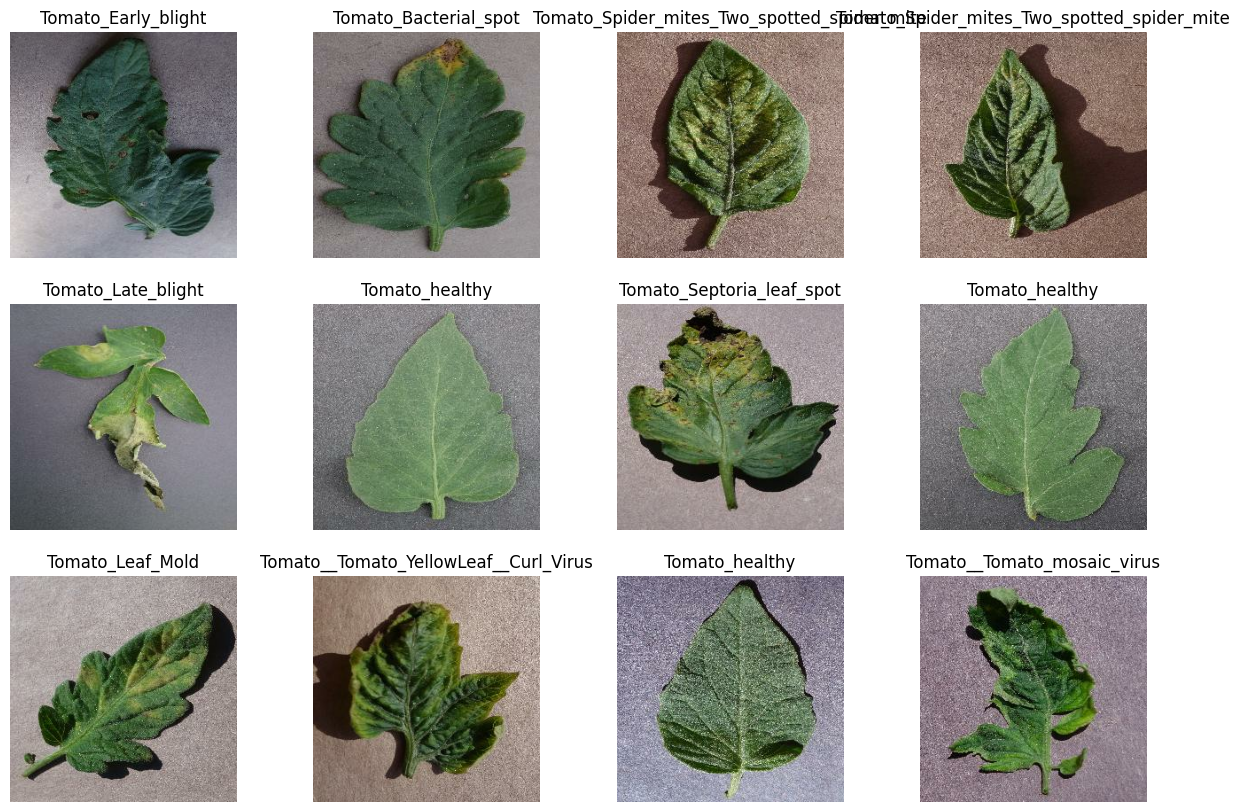

In [54]:
plt.figure(figsize=(15, 10))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [55]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [56]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [57]:
len(train_ds), len(val_ds), len(test_ds)

(400, 50, 51)

In [58]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [59]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])


In [60]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [61]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = len(class_names)

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax')
])

model.build(input_shape=(None, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))


In [62]:
model.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_9 (Sequential)   (None, 256, 256, 3)       0         
                                                                 
 sequential_10 (Sequential)  (None, 256, 256, 3)       0         
                                                                 
 conv2d_15 (Conv2D)          (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d_15 (MaxPooli  (None, 127, 127, 32)      0         
 ng2D)                                                           
                                                                 
 conv2d_16 (Conv2D)          (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_16 (MaxPooli  (None, 62, 62, 64)        0         
 ng2D)                                               

In [63]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [64]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("../saved_models/best_model.h5", save_best_only=True, monitor='val_loss')
]

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
    validation_data=val_ds
)


Epoch 1/25
400/400 [==============================] - ETA: 0s - loss: 1.0890 - accuracy: 0.6290

c:\---MY FILES---\Projects\Tomato Disease Classification\venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


400/400 [==============================] - 407s 891ms/step - loss: 1.0890 - accuracy: 0.6290 - val_loss: 2.6416 - val_accuracy: 0.2169
Epoch 2/25
400/400 [==============================] - 380s 950ms/step - loss: 0.7332 - accuracy: 0.7477 - val_loss: 5.2294 - val_accuracy: 0.3456
Epoch 3/25
400/400 [==============================] - 315s 789ms/step - loss: 0.6333 - accuracy: 0.7794 - val_loss: 3.6369 - val_accuracy: 0.4125
Epoch 4/25
400/400 [==============================] - 331s 829ms/step - loss: 0.5620 - accuracy: 0.8009 - val_loss: 0.7095 - val_accuracy: 0.7631
Epoch 5/25
400/400 [==============================] - 331s 828ms/step - loss: 0.4805 - accuracy: 0.8323 - val_loss: 1.3225 - val_accuracy: 0.6981
Epoch 6/25
400/400 [==============================] - 360s 901ms/step - loss: 0.4573 - accuracy: 0.8402 - val_loss: 0.6415 - val_accuracy: 0.8138
Epoch 7/25
400/400 [==============================] - 337s 844ms/step - loss: 0.4243 - accuracy: 0.8549 - val_loss: 2.3157 - val_accura

In [65]:
scores = model.evaluate(test_ds)

51/51 [==============================] - 53s 167ms/step - loss: 0.4463 - accuracy: 0.8591


In [66]:
scores

[0.44625797867774963, 0.8590686321258545]

In [67]:
history.params

{'verbose': 1, 'epochs': 25, 'steps': 400}

In [68]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [69]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation Loss')

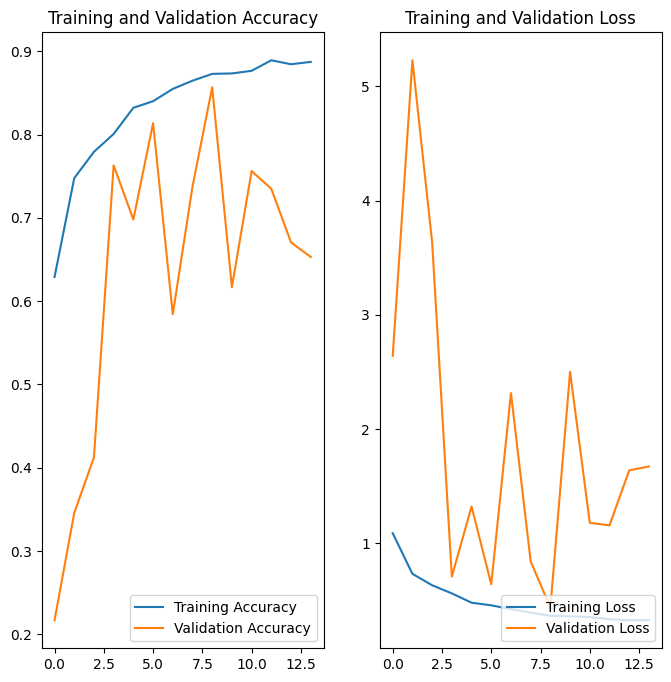

In [71]:
plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.plot(range(len(acc)), acc, label="Training Accuracy")
plt.plot(range(len(acc)), val_acc, label="Validation Accuracy")
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(range(len(loss)), loss, label="Training Loss")
plt.plot(range(len(loss)), val_loss, label="Validation Loss")
plt.legend(loc='lower right')
plt.title("Training and Validation Loss")


First image to predict
First image's actual label:  Tomato_Spider_mites_Two_spotted_spider_mite
1/1 [==============================] - 0s 139ms/step
First image's predicted label:  Tomato_Spider_mites_Two_spotted_spider_mite


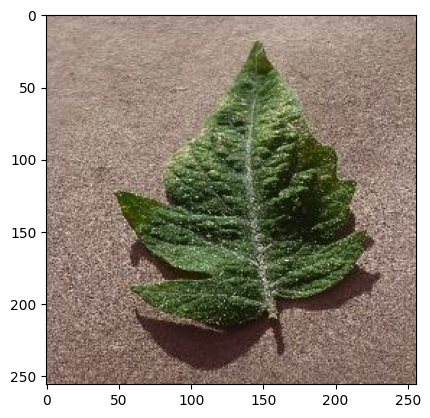

In [85]:
for images_batch, labels_batch in test_ds.take(1):

    first_image = images_batch[0].numpy().astype("uint8")
    first_label = labels_batch[0]

    print("First image to predict")
    plt.imshow(first_image)
    print("First image's actual label: ", class_names[first_label])

    batch_prediction = model.predict(images_batch)
    print("First image's predicted label: ", class_names[np.argmax(batch_prediction[0])])


In [86]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)    # Create a batch
    img_array = img_array / 255.0

    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * float(np.max(predictions[0])), 2)
    return predicted_class, confidence


1/1 [==============================] - 0s 25ms/step


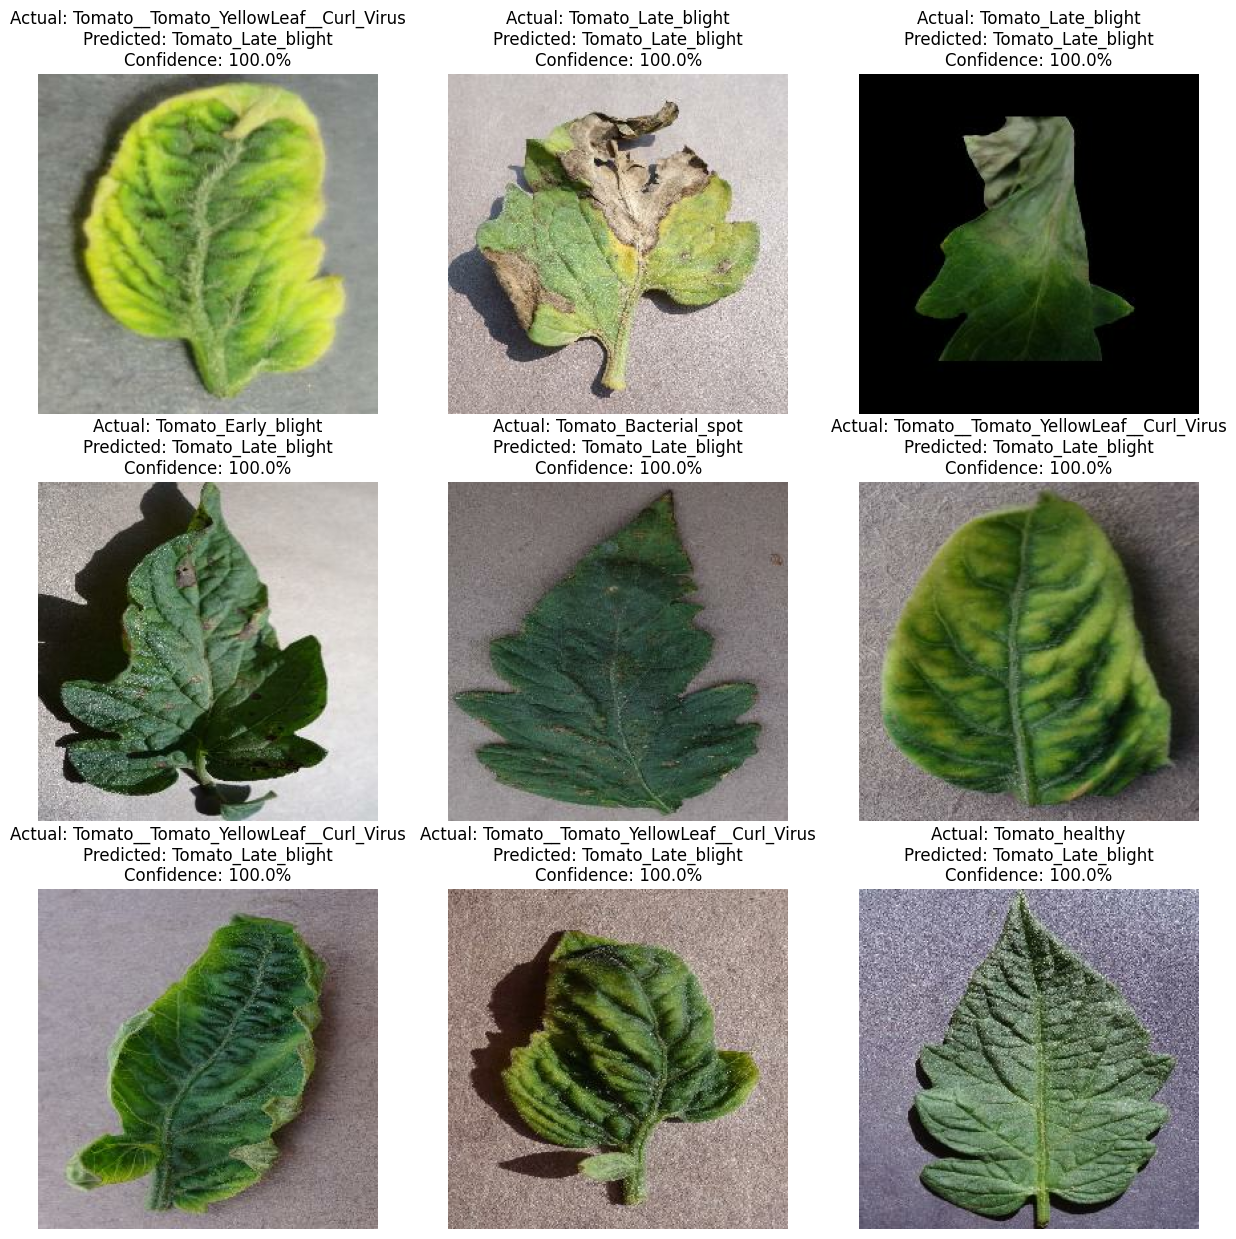

In [87]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i  + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%")

        plt.axis("off")

In [88]:
model.save(f"../saved_models/0")

INFO:tensorflow:Assets written to: ../saved_models/0\assets


INFO:tensorflow:Assets written to: ../saved_models/0\assets


In [89]:
# import os
# model_version = max([int(i) for i in os.listdir("../saved_models")]) + 1
# model.save(f"../saved_models/{model_version}")

In [90]:
model.save("../model.h5")

c:\---MY FILES---\Projects\Tomato Disease Classification\venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
